In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap

EMB_PATH = "/home/adickson/rice_data/sativas413_embeddings.pt"

In [24]:
data = torch.load(EMB_PATH, weights_only=True)
embeddings  = data["embeddings"].float().numpy()   # (413, 768)
sample_ids  = data["sample_ids"]

print(f"{embeddings.shape[0]} samples  ×  {embeddings.shape[1]} dims")

413 samples  ×  768 dims


In [25]:
# BERT embeddings live in a narrow cone — subtract the mean to remove that constant
# direction before any analysis, otherwise PC1 captures ~100% of variance trivially.
embeddings_centered = embeddings - embeddings.mean(axis=0)

In [26]:
# ── Embedding variance diagnostic ──────────────────────────────────────────────
# If SNPs weren't incorporated, all sample embeddings will be nearly identical
# (differing only by floating-point noise). These numbers distinguish that from
# genuine but low-dimensional variation.

per_dim_std = embeddings_centered.std(axis=0)          # std across samples per dim
mean_l2     = np.linalg.norm(embeddings_centered, axis=1).mean()  # mean L2 from centroid

# Sample 200 random pairs and compute L2 distances
rng  = np.random.default_rng(0)
idx  = rng.integers(0, len(embeddings_centered), size=(200, 2))
pair_dists = np.linalg.norm(
    embeddings_centered[idx[:, 0]] - embeddings_centered[idx[:, 1]], axis=1
)

print(f"Per-dim std  — mean: {per_dim_std.mean():.5f}  max: {per_dim_std.max():.5f}")
print(f"Mean L2 from centroid : {mean_l2:.5f}")
print(f"Pairwise L2 — mean: {pair_dists.mean():.5f}  max: {pair_dists.max():.5f}")
print()
print("Interpretation:")
print("  If pairwise L2 ≈ 0 → embeddings are identical → SNPs not being applied")
print("  If pairwise L2 > 0 but small → SNPs applied but window context dominates")

Per-dim std  — mean: 0.00004  max: 0.00317
Mean L2 from centroid : 0.00291
Pairwise L2 — mean: 0.00388  max: 0.01167

Interpretation:
  If pairwise L2 ≈ 0 → embeddings are identical → SNPs not being applied
  If pairwise L2 > 0 but small → SNPs applied but window context dominates


In [27]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
coords  = reducer.fit_transform(embeddings_centered)
print("UMAP done:", coords.shape)

/home/adickson/miniconda3/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done: (413, 2)


In [28]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=50, min_dist=0.03)
coords  = reducer.fit_transform(embeddings)   # (413, 2)
print("UMAP done:", coords.shape)

/home/adickson/miniconda3/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done: (413, 2)


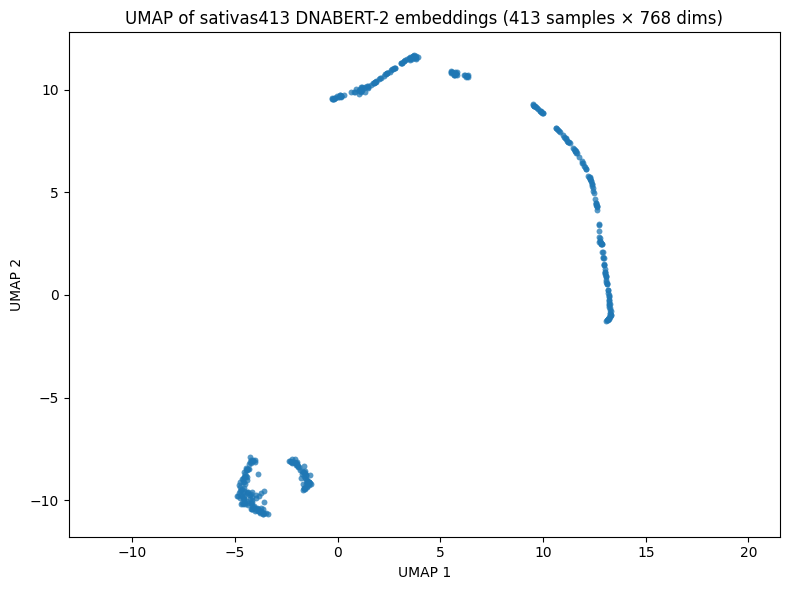

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(coords[:, 0], coords[:, 1], s=18, alpha=0.75, linewidths=0)

ax.set_title("UMAP of sativas413 DNABERT-2 embeddings (413 samples × 768 dims)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_aspect("equal", "datalim")

plt.tight_layout()
plt.show()